In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROJECT_ROOT = Path.cwd().parent
RAW_CME = PROJECT_ROOT / 'data' / 'raw' / 'cme' / 'btc_future_options_data.csv'
RAW_DERIBIT = PROJECT_ROOT / 'data' / 'raw' / 'deribit' / 'btc_options_trades.parquet'
ZERO_CURVE = PROJECT_ROOT / 'data' / 'raw' / 'cme' / 'Zero_curve_USD.csv'

#### 1. CME Raw Data (IvyDB Futures v3.0)

In [13]:
# Load only essential columns for fast inspection
cme_cols = ['date', 'expiration', 'strike', 'callput', 'futuresettlementprice',
            'settlementprice', 'bid', 'offer', 'impliedvolatility',
            'volume', 'openinterest', 'exercisestyle']
cme = pd.read_csv(RAW_CME, usecols=cme_cols, low_memory=False)
cme['date'] = pd.to_datetime(cme['date'])
cme['expiration'] = pd.to_datetime(cme['expiration'])

print(f"Raw rows: {len(cme):,}")
print(f"Date range: {cme['date'].min().date()} → {cme['date'].max().date()}")
print(f"Unique dates: {cme['date'].nunique():,}")
print(f"Calls/Puts: {(cme['callput']=='C').sum():,} / {(cme['callput']=='P').sum():,}")
print(f"Exercise style: {cme['exercisestyle'].value_counts().to_dict()}")

Raw rows: 2,632,319
Date range: 2020-01-13 → 2023-08-31
Unique dates: 914
Calls/Puts: 1,457,763 / 1,174,556
Exercise style: {'E': 2632319}


In [14]:
# Sentinel value diagnostics
print("Sentinel (-99.99) coverage:")
for col in ['impliedvolatility', 'bid', 'offer']:
    n_sent = (cme[col] == -99.99).sum()
    print(f"  {col:<25}: {n_sent:>10,} ({n_sent/len(cme):>5.1%})")

print("\nLiquidity profile:")
print(f"  Volume == 0:        {(cme['volume']==0).sum():>10,} ({(cme['volume']==0).mean():.1%})")
print(f"  OI == 0:            {(cme['openinterest']==0).sum():>10,} ({(cme['openinterest']==0).mean():.1%})")
print(f"  Volume>0 or OI>0:   {((cme['volume']>0)|(cme['openinterest']>0)).sum():>10,}")

Sentinel (-99.99) coverage:
  impliedvolatility        :     37,786 ( 1.4%)
  bid                      :  2,127,726 (80.8%)
  offer                    :  1,871,506 (71.1%)

Liquidity profile:
  Volume == 0:         2,583,536 (98.1%)
  OI == 0:             2,491,638 (94.7%)
  Volume>0 or OI>0:      145,664


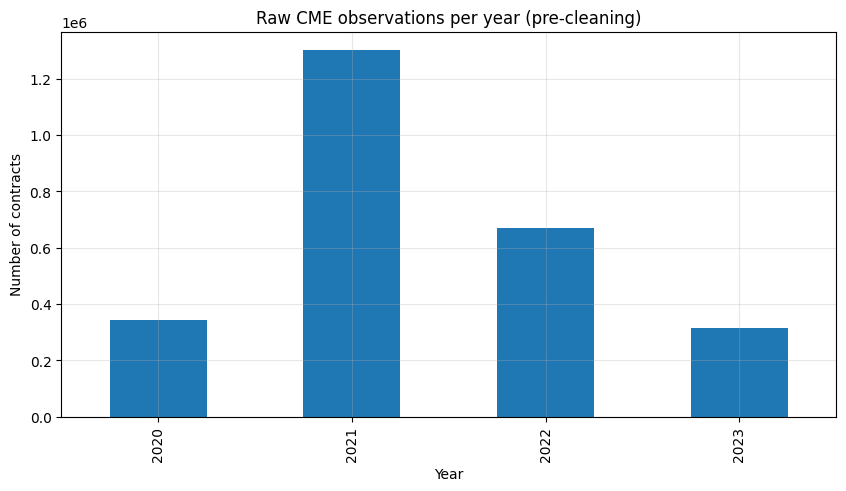

date
2020     344720
2021    1302062
2022     671186
2023     314351
dtype: int64


In [15]:
# Yearly distribution of raw contracts
yearly_cme = cme.groupby(cme['date'].dt.year).size()
yearly_cme.plot(kind='bar')
plt.title('Raw CME observations per year (pre-cleaning)')
plt.ylabel('Number of contracts')
plt.xlabel('Year')
plt.show()
print(yearly_cme)

Days-to-expiry distribution:
count    2.632319e+06
mean     1.352701e+02
std      1.552474e+02
min      0.000000e+00
25%      3.500000e+01
50%      8.000000e+01
75%      1.580000e+02
max      7.360000e+02
Name: dte, dtype: float64


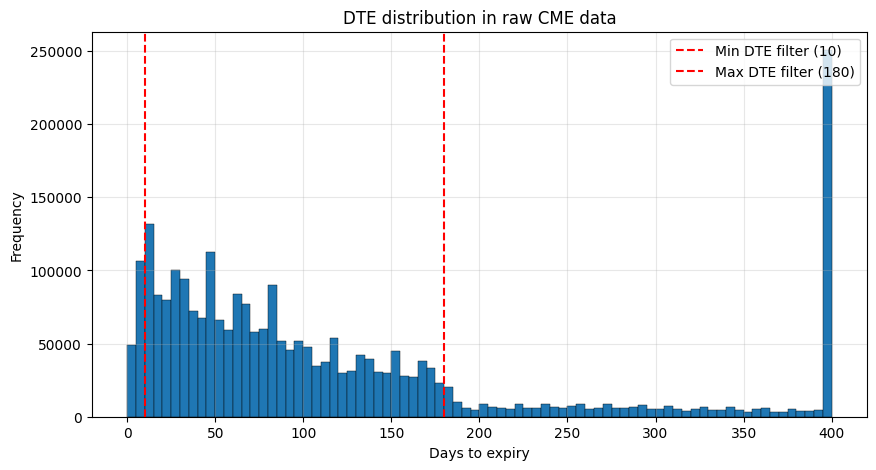

In [16]:
# Distribution of days to expiry in raw data
cme['dte'] = (cme['expiration'] - cme['date']).dt.days
print("Days-to-expiry distribution:")
print(cme['dte'].describe())

fig, ax = plt.subplots()
ax.hist(cme['dte'].clip(upper=400), bins=80, edgecolor='black', linewidth=0.3)
ax.axvline(10, color='red', linestyle='--', label='Min DTE filter (10)')
ax.axvline(180, color='red', linestyle='--', label='Max DTE filter (180)')
ax.set_xlabel('Days to expiry')
ax.set_ylabel('Frequency')
ax.set_title('DTE distribution in raw CME data')
ax.legend()
plt.show()

#### 2. Deribit Raw Data (scraped trades)

In [17]:
# Read summary only (avoid loading all 21M rows)
der = pd.read_parquet(RAW_DERIBIT, columns=['date', 'callput', 'iv', 'amount', 'days_to_expiry'])

print(f"Raw trades: {len(der):,}")
print(f"Date range: {der['date'].min().date()} → {der['date'].max().date()}")
print(f"Unique dates: {der['date'].nunique():,}")
print(f"Calls/Puts: {(der['callput']=='C').sum():,} / {(der['callput']=='P').sum():,}")

Raw trades: 21,807,277
Date range: 2017-07-01 → 2025-12-30
Unique dates: 3,105
Calls/Puts: 11,836,515 / 9,970,762


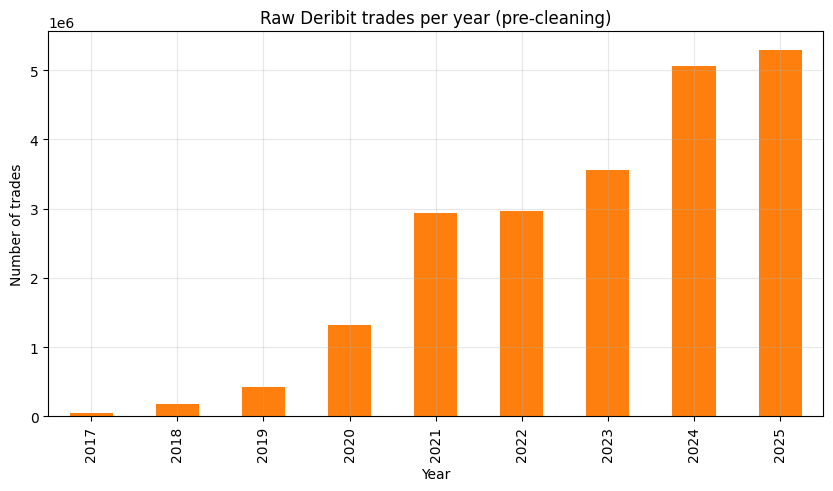

date
2017      50868
2018     186575
2019     432504
2020    1324730
2021    2933040
2022    2963267
2023    3563984
2024    5057575
2025    5294734
dtype: int64


In [18]:
# Yearly distribution
yearly_der = der.groupby(der['date'].dt.year).size()
yearly_der.plot(kind='bar', color='C1')
plt.title('Raw Deribit trades per year (pre-cleaning)')
plt.ylabel('Number of trades')
plt.xlabel('Year')
plt.show()
print(yearly_der)

In [19]:
# IV distribution (already in decimal form from scraper)
print("IV statistics (raw, already divided by 100 in scraper):")
print(der['iv'].describe())

print(f"\nIV == 0:   {(der['iv']==0).sum():,}")
print(f"IV  < 0:   {(der['iv']<0).sum():,}")
print(f"IV NaN:    {der['iv'].isna().sum():,}")
print(f"IV  > 5:   {(der['iv']>5).sum():,}")

IV statistics (raw, already divided by 100 in scraper):
count    2.180728e+07
mean     6.634998e-01
std      3.313925e-01
min      0.000000e+00
25%      4.716000e-01
50%      5.974000e-01
75%      7.759000e-01
max      9.990000e+00
Name: iv, dtype: float64

IV == 0:   78,536
IV  < 0:   0
IV NaN:    0
IV  > 5:   5,653


Trade amount (BTC contracts) distribution:
count    2.180728e+07
mean     2.117870e+00
std      1.265118e+01
min      0.000000e+00
25%      1.000000e-01
50%      3.000000e-01
75%      1.000000e+00
max      8.000000e+03
Name: amount, dtype: float64


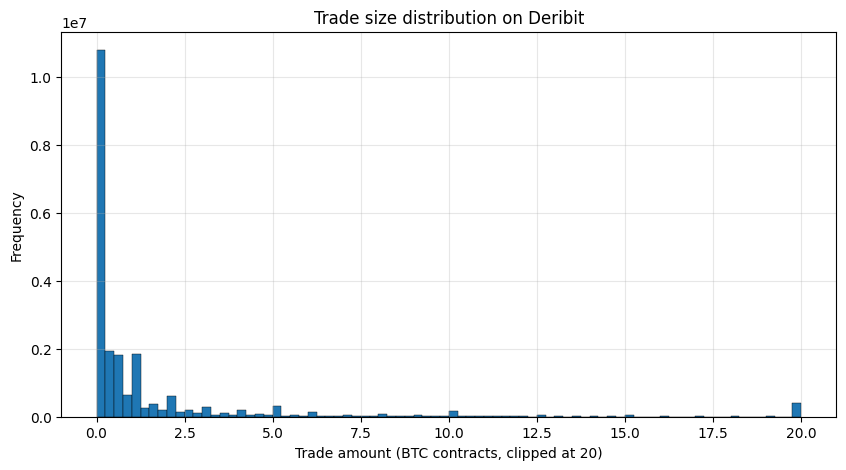

In [20]:
# Trade size distribution
print("Trade amount (BTC contracts) distribution:")
print(der['amount'].describe())

fig, ax = plt.subplots()
ax.hist(der['amount'].clip(upper=20), bins=80, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Trade amount (BTC contracts, clipped at 20)')
ax.set_ylabel('Frequency')
ax.set_title('Trade size distribution on Deribit')
plt.show()

#### 3. Zero Curve (OptionMetrics USD)

In [21]:
zc = pd.read_csv(ZERO_CURVE, parse_dates=['date'])
zc = zc[zc['currency'] == 'USD'].copy()

print(f"Rows: {len(zc):,}")
print(f"Date range: {zc['date'].min().date()} → {zc['date'].max().date()}")
print(f"Unique tenors (days): {sorted(zc['days'].unique())}")

Rows: 197,977
Date range: 2005-01-03 → 2023-08-31
Unique tenors (days): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67)

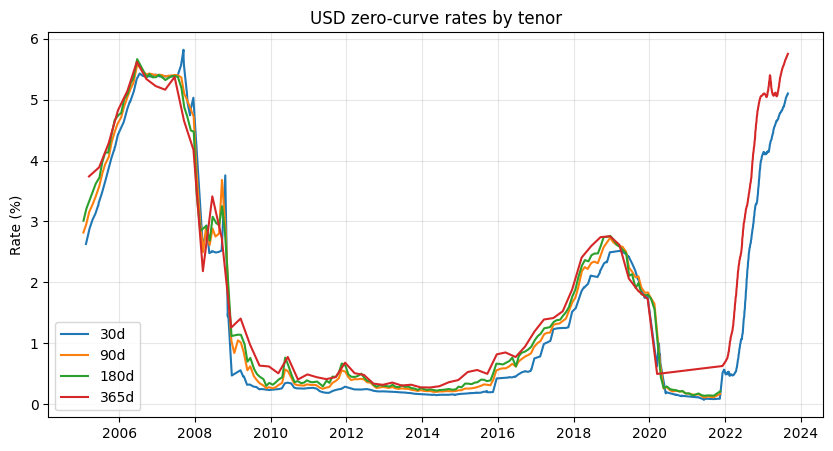

In [22]:
# Plot the rate term structure across time at selected tenors
selected_tenors = [30, 90, 180, 365]
fig, ax = plt.subplots()
for tenor in selected_tenors:
    ts = zc[zc['days'] == tenor].set_index('date')['rate']
    ax.plot(ts.index, ts.values * 100, label=f'{tenor}d')
ax.set_ylabel('Rate (%)')
ax.set_title('USD zero-curve rates by tenor')
ax.legend()
plt.show()